In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Завантаження даних
ab_test = pd.read_csv('ab_test.csv')
clients = pd.read_csv('clients.csv')
products = pd.read_csv('products.csv')
sales = pd.read_csv('sales.csv')

# Швидка перевірка, що дані завантажились успішно
print("Таблиці завантажено успішно!")
print(f" sales: {sales.shape} | clients: {clients.shape} | products: {products.shape} | ab_test: {ab_test.shape}")

Таблиці завантажено успішно!
 sales: (1000, 8) | clients: (1000, 6) | products: (100, 5) | ab_test: (1000, 2)


/tmp/ipykernel_55070/534207820.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=total_channels, x='sales_channel', y='total_margin_%', palette=colors)


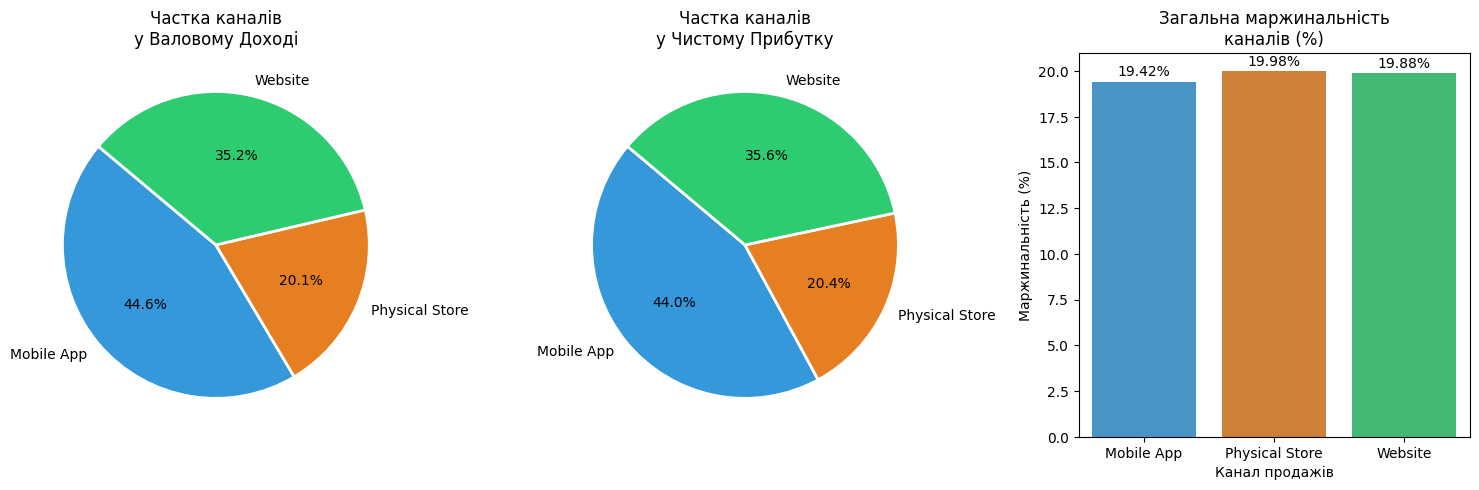

In [2]:
# Фільтруємо успішні замовлення та об'єднуємо з цінами товарів
completed_sales = sales[sales['order_status'] == 'Completed'].copy()
df_finance = pd.merge(completed_sales, products, on='product_id', how='left')

# Розрахунок фінансових метрик
df_finance['revenue'] = df_finance['quantity'] * df_finance['retail_price']
df_finance['cost'] = df_finance['quantity'] * df_finance['cost_price']
df_finance['profit'] = df_finance['revenue'] - df_finance['cost']

# Агрегація даних за каналами продажів (sales_channel) за весь період
total_channels = df_finance.groupby('sales_channel').agg(
    total_revenue=('revenue', 'sum'),
    total_profit=('profit', 'sum')
).reset_index()

# Розрахунок загальної маржинальності (%)
total_channels['total_margin_%'] = (total_channels['total_profit'] / total_channels['total_revenue']) * 100

# Візуалізація (Кругові діаграми + Стовпчаста)
plt.figure(figsize=(15, 5))
colors = ['#3498db', '#e67e22', '#2ecc71']

# Діаграма 1: Валовий Дохід
plt.subplot(1, 3, 1)
plt.pie(total_channels['total_revenue'],
        labels=total_channels['sales_channel'],
        autopct='%1.1f%%',
        startangle=140,
        colors=colors,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})
plt.title('Частка каналів\nу Валовому Доході')

# Діаграма 2: Чистий Прибуток
plt.subplot(1, 3, 2)
plt.pie(total_channels['total_profit'],
        labels=total_channels['sales_channel'],
        autopct='%1.1f%%',
        startangle=140,
        colors=colors,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})
plt.title('Частка каналів\nу Чистому Прибутку')

# Діаграма 3: Маржинальність
plt.subplot(1, 3, 3)
sns.barplot(data=total_channels, x='sales_channel', y='total_margin_%', palette=colors)
plt.title('Загальна маржинальність\nканалів (%)')
plt.ylabel('Маржинальність (%)')
plt.xlabel('Канал продажів')

# Додаємо цифри над стовпчиками маржинальності
for index, row in total_channels.iterrows():
    plt.text(index, row['total_margin_%'] + 0.3, f"{row['total_margin_%']:.2f}%", color='black', ha="center")

plt.tight_layout()
plt.show()

/tmp/ipykernel_55070/2633497370.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=age_group_counts, x='age_group', y='count', palette='Blues_r', ax=axes[1])


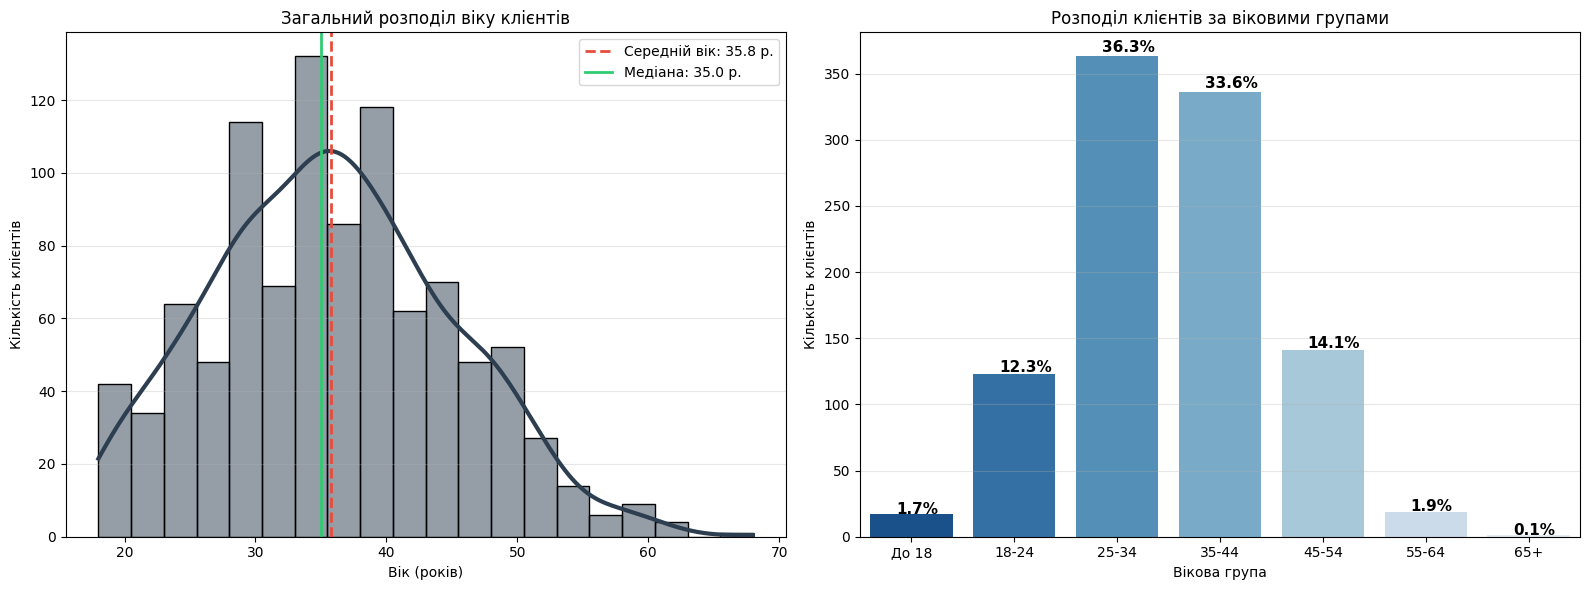

📊 Базова статистика віку клієнтів:
Наймолодший клієнт: 18 років
Найстарший клієнт: 68 років
Середній вік: 35.80 років
Медіанний вік: 35.0 років


In [3]:
# Очищення: прибираємо пусті значення у колонці віку, якщо вони є
age_data = clients['age'].dropna()

# Налаштування графіків (робимо два варіанти для максимальної наочності)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Графік 1: Гістограма щільності розподілу (плавна лінія + стовпчики)
sns.histplot(age_data, kde=True, color='#2c3e50', ax=axes[0], bins=20, line_kws={'linewidth': 3})
axes[0].axvline(age_data.mean(), color='#e74c3c', linestyle='--', linewidth=2, label=f"Середній вік: {age_data.mean():.1f} р.")
axes[0].axvline(age_data.median(), color='#2ecc71', linestyle='-', linewidth=2, label=f"Медіана: {age_data.median():.1f} р.")
axes[0].set_title('Загальний розподіл віку клієнтів')
axes[0].set_xlabel('Вік (років)')
axes[0].set_ylabel('Кількість клієнтів')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Графік 2: Стовпчаста діаграма за стандартними віковими групами
bins = [0, 18, 25, 35, 45, 55, 65, 100]
labels = ['До 18', '18-24', '25-34', '35-44', '45-54', '55-64', '65+']
clients['age_group'] = pd.cut(clients['age'], bins=bins, labels=labels)

age_group_counts = clients['age_group'].value_counts().reindex(labels).reset_index()

sns.barplot(data=age_group_counts, x='age_group', y='count', palette='Blues_r', ax=axes[1])
axes[1].set_title('Розподіл клієнтів за віковими групами')
axes[1].set_xlabel('Вікова група')
axes[1].set_ylabel('Кількість клієнтів')
axes[1].grid(axis='y', alpha=0.3)

# Додаємо відсотки над стовпчиками другої діаграми
total_clients = len(age_data)
for p in axes[1].patches:
    height = p.get_height()
    if height > 0:
        percentage = f'{100 * height / total_clients:.1f}%'
        x = p.get_x() + p.get_width() / 2 - 0.15
        y = height + (height * 0.01)
        axes[1].annotate(percentage, (x, y), fontsize=11, weight='bold')

plt.tight_layout()
plt.show()

# Вивід базових статистичних показників в текст
print("📊 Базова статистика віку клієнтів:")
print(f"Наймолодший клієнт: {age_data.min()} років")
print(f"Найстарший клієнт: {age_data.max()} років")
print(f"Середній вік: {age_data.mean():.2f} років")
print(f"Медіанний вік: {age_data.median()} років")

/tmp/ipykernel_55070/3877772786.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=city_counts, x='client_count', y='city', palette='viridis')


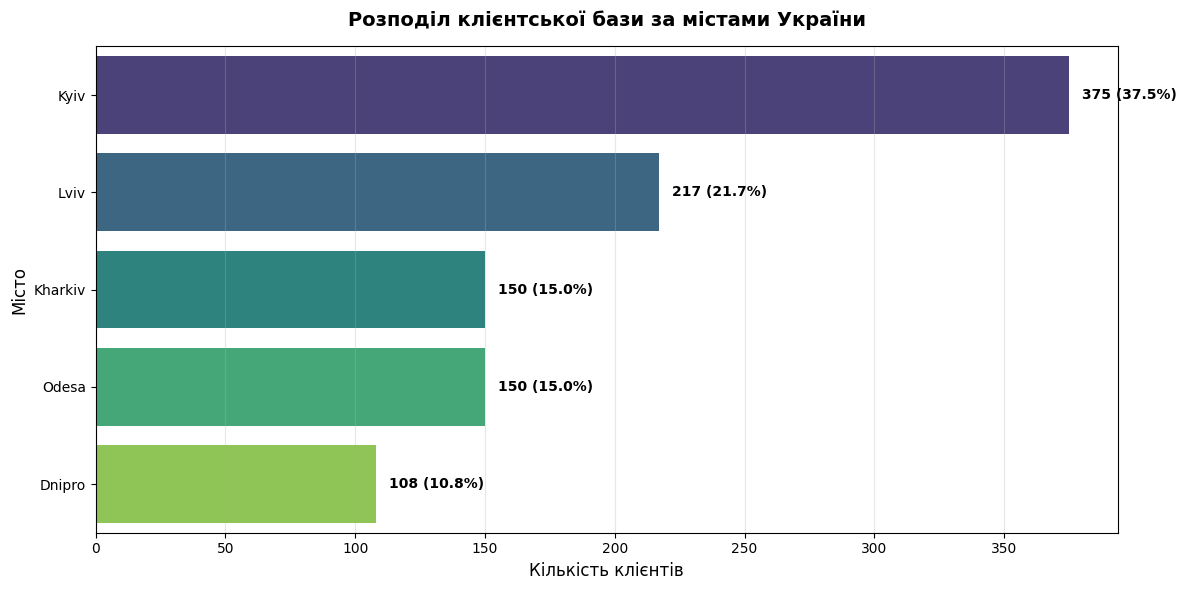

📊 Географічна статистика клієнтів:
   city  client_count  percentage_%
   Kyiv           375          37.5
   Lviv           217          21.7
Kharkiv           150          15.0
  Odesa           150          15.0
 Dnipro           108          10.8


In [4]:
# Рахуємо кількість клієнтів та їхню частку по містах
city_counts = clients['city'].value_counts().reset_index()
city_counts.columns = ['city', 'client_count']

# Додаємо відсоток від загальної кількості
total_clients = city_counts['client_count'].sum()
city_counts['percentage_%'] = (city_counts['client_count'] / total_clients) * 100

# Побудова графіка
plt.figure(figsize=(12, 6))

# Використовуємо горизонтальний бар-чарт для кращого читання назв міст
sns.barplot(data=city_counts, x='client_count', y='city', palette='viridis')

plt.title('Розподіл клієнтської бази за містами України', fontsize=14, weight='bold', pad=15)
plt.xlabel('Кількість клієнтів', fontsize=12)
plt.ylabel('Місто', fontsize=12)
plt.grid(axis='x', alpha=0.3)

# Додаємо текстові мітки з кількістю та % всередину або поруч зі стовпчиками
for index, row in city_counts.iterrows():
    label = f"{row['client_count']} ({row['percentage_%']:.1f}%)"
    plt.text(row['client_count'] + (total_clients * 0.005), index, label,
             va='center', ha='left', fontsize=10, weight='bold')

plt.tight_layout()
plt.show()

# Текстовий вивід для швидкої перевірки
print("📊 Географічна статистика клієнтів:")
print(city_counts.to_string(index=False))

/tmp/ipykernel_55070/3340679398.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=brand_stats, x='total_revenue', y='brand', palette='coolwarm', ax=axes[0])


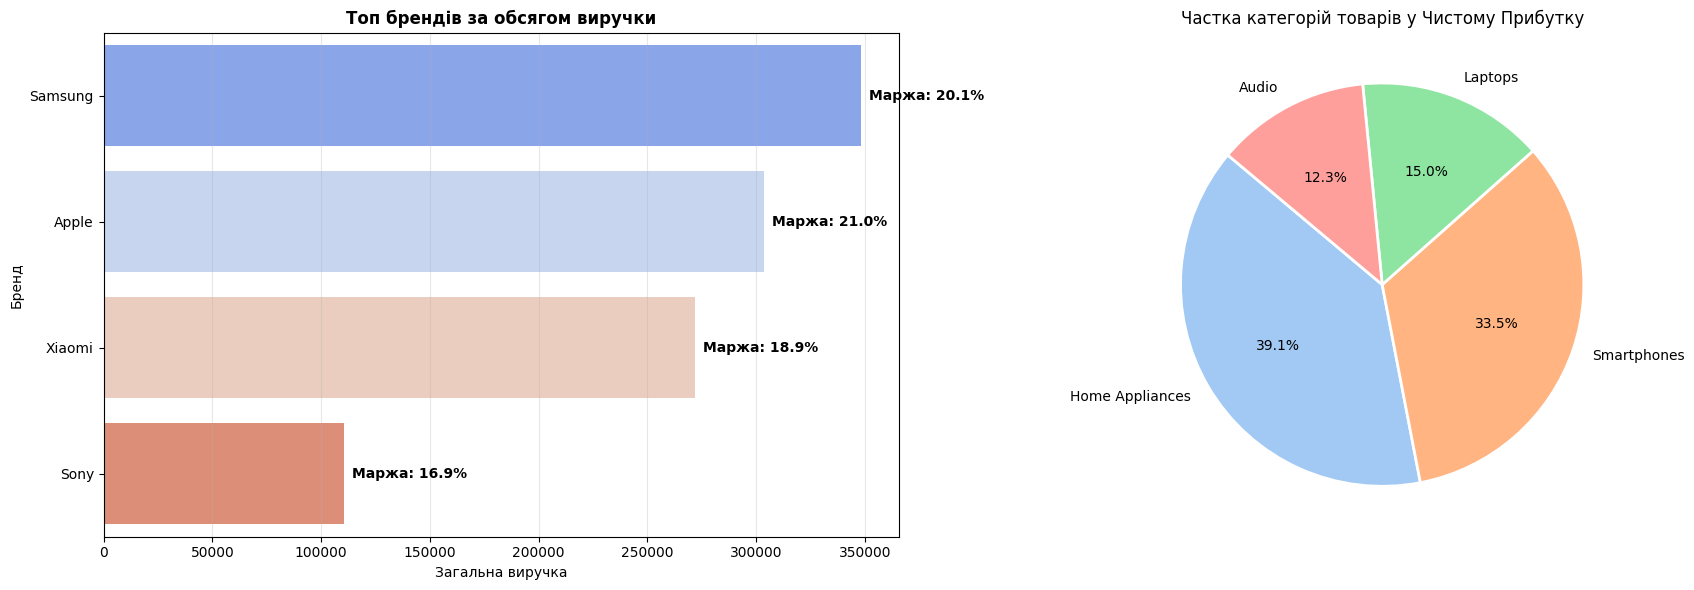

📊 Фінансова статистика брендів:
  brand  total_revenue  total_profit  margin_pct
Samsung      348367.48      69993.33   20.091809
  Apple      303728.95      63712.23   20.976673
 Xiaomi      271998.51      51327.26   18.870420
   Sony      110471.65      18718.16   16.943858


In [5]:
# Фільтруємо успішні замовлення та об'єднуємо з довідником продуктів
completed_sales = sales[sales['order_status'] == 'Completed'].copy()
df_products = pd.merge(completed_sales, products, on='product_id', how='left')

# Розрахунок фінансових метрик для кожного рядка
df_products['revenue'] = df_products['quantity'] * df_products['retail_price']
df_products['cost'] = df_products['quantity'] * df_products['cost_price']
df_products['profit'] = df_products['revenue'] - df_products['cost']

# Агрегація даних за брендами
brand_stats = df_products.groupby('brand').agg(
    total_revenue=('revenue', 'sum'),
    total_profit=('profit', 'sum')
).reset_index()
brand_stats['margin_pct'] = (brand_stats['total_profit'] / brand_stats['total_revenue']) * 100
brand_stats = brand_stats.sort_values(by='total_revenue', ascending=False).reset_index(drop=True)

# Агрегація даних за категоріями товарів
category_stats = df_products.groupby('category').agg(
    total_profit=('profit', 'sum')
).reset_index().sort_values(by='total_profit', ascending=False)

# Візуалізація результатів
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Графік 1: Топ брендів за виручкою + відображення маржі
sns.barplot(data=brand_stats, x='total_revenue', y='brand', palette='coolwarm', ax=axes[0])
axes[0].set_title('Топ брендів за обсягом виручки', fontsize=12, weight='bold')
axes[0].set_xlabel('Загальна виручка')
axes[0].set_ylabel('Бренд')
axes[0].grid(axis='x', alpha=0.3)

# Додаємо маржинальність текстом на графік брендів через iterrows
for index, row in brand_stats.iterrows():
    axes[0].text(row['total_revenue'] + (brand_stats['total_revenue'].max() * 0.01), index,
                 f"Маржа: {row['margin_pct']:.1f}%", va='center', fontsize=10, weight='bold')

# Графік 2: Кругова діаграма чистого прибутку за категоріями товарів
axes[1].pie(category_stats['total_profit'],
            labels=category_stats['category'],
            autopct='%1.1f%%',
            startangle=140,
            colors=sns.color_palette('pastel'),
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].title.set_text('Частка категорій товарів у Чистому Прибутку')

plt.tight_layout()
plt.show()

# Текстовий вивід для детального аналізу
print("📊 Фінансова статистика брендів:")
print(brand_stats[['brand', 'total_revenue', 'total_profit', 'margin_pct']].to_string(index=False))

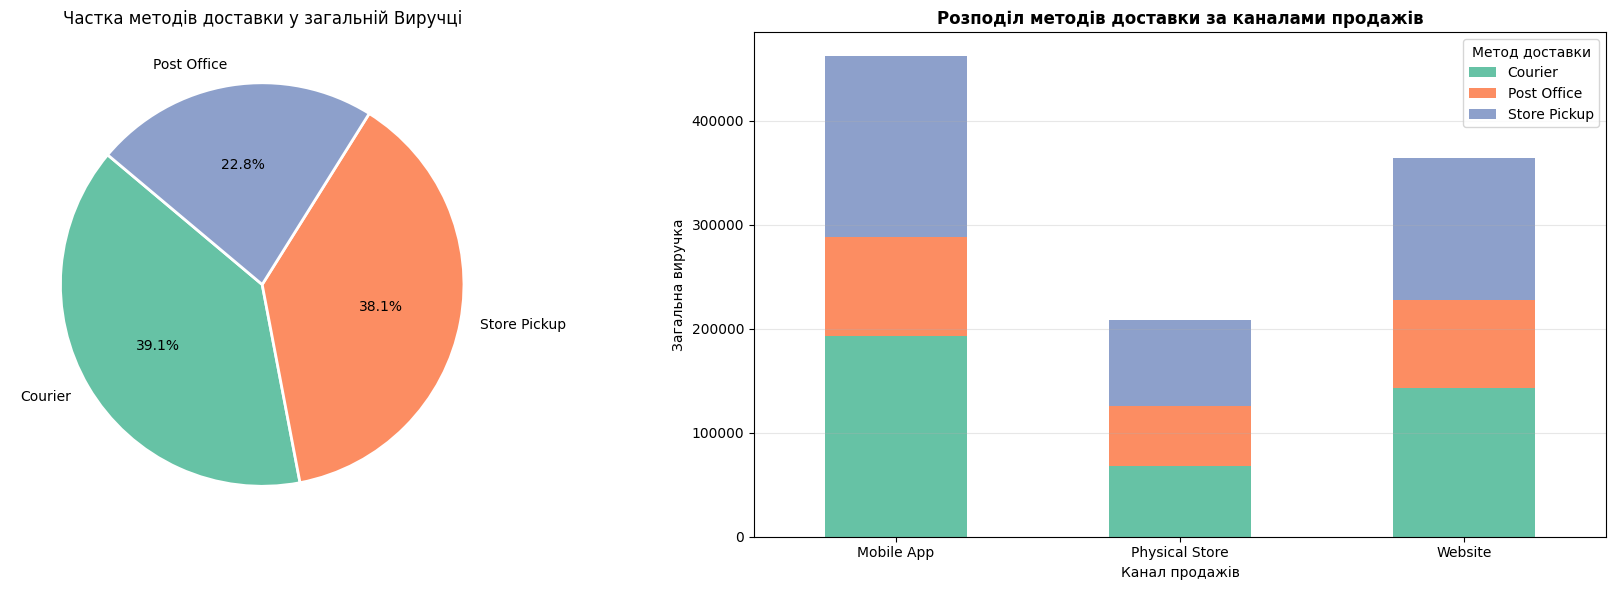

📊 Статистика методів доставки:
delivery_method  total_revenue  order_count
        Courier      404660.39          375
   Store Pickup      394120.42          347
    Post Office      235785.78          210


In [6]:
# Фільтруємо успішні замовлення та об'єднуємо з продуктами для розрахунку виручки
completed_sales = sales[sales['order_status'] == 'Completed'].copy()
df_delivery = pd.merge(completed_sales, products, on='product_id', how='left')

# Розрахунок виручки
df_delivery['revenue'] = df_delivery['quantity'] * df_delivery['retail_price']

# Агрегація даних: загальна виручка за методами доставки
delivery_stats = df_delivery.groupby('delivery_method').agg(
    total_revenue=('revenue', 'sum'),
    order_count=('transaction_id', 'count')
).reset_index().sort_values(by='total_revenue', ascending=False)

# Перехресне групування: методи доставки в розрізі каналів продажів (sales_channel)
delivery_by_channel = df_delivery.groupby(['sales_channel', 'delivery_method'])['revenue'].sum().unstack().fillna(0)

# Візуалізація
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Графік 1: Кругова діаграма загальної виручки за методами доставки
axes[0].pie(delivery_stats['total_revenue'],
            labels=delivery_stats['delivery_method'],
            autopct='%1.1f%%',
            startangle=140,
            colors=sns.color_palette('Set2'),
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].title.set_text('Частка методів доставки у загальній Виручці')

# Графік 2: Стовпчаста діаграма доставки у розрізі каналів продажів
delivery_by_channel.plot(kind='bar', stacked=True, ax=axes[1], color=sns.color_palette('Set2'))
axes[1].set_title('Розподіл методів доставки за каналами продажів', fontsize=12, weight='bold')
axes[1].set_xlabel('Канал продажів')
axes[1].set_ylabel('Загальна виручка')
axes[1].set_xticklabels(delivery_by_channel.index, rotation=0)
axes[1].grid(axis='y', alpha=0.3)
axes[1].legend(title='Метод доставки')

plt.tight_layout()
plt.show()

# Текстовий вивід для аналізу
print("📊 Статистика методів доставки:")
print(delivery_stats.to_string(index=False))

/tmp/ipykernel_55070/3466006809.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=aov_by_channel, x='sales_channel', y='AOV', palette='Blues_r', ax=axes[0])
/tmp/ipykernel_55070/3466006809.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=aov_by_city, x='city', y='AOV', palette='magma', ax=axes[1])


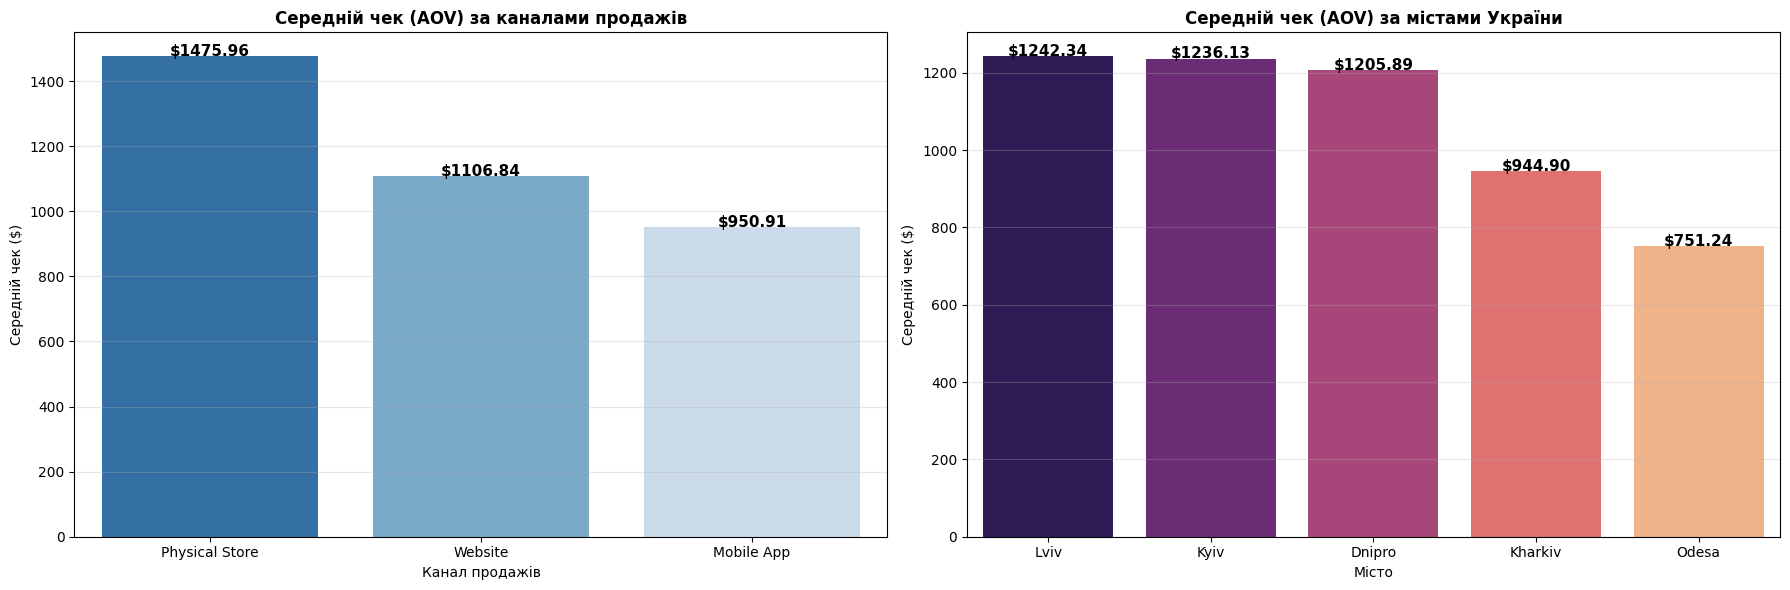

📊 Середній чек за каналами продажів:
 sales_channel         AOV
Physical Store 1475.958125
       Website 1106.843846
    Mobile App  950.907778

📊 Середній чек за містами:
   city         AOV
   Lviv 1242.340000
   Kyiv 1236.133077
 Dnipro 1205.892500
Kharkiv  944.895455
  Odesa  751.236250


In [7]:
# 1. Фільтруємо успішні замовлення та об'єднуємо з продуктами та клієнтами
completed_sales = sales[sales['order_status'] == 'Completed'].copy()
df_aov = pd.merge(completed_sales, products, on='product_id', how='left')
df_aov = pd.merge(df_aov, clients, on='client_id', how='left')

# 2. Розраховуємо вартість кожної позиції (кількість * ціна)
df_aov['item_total'] = df_aov['quantity'] * df_aov['retail_price']

# 3. Рахуємо суму кожного чека (групуємо за транзакцією, зберігаючи канал та місто)
# Примітка: якщо в одній транзакції кілька товарів, ми їх сумуємо, щоб отримати повний чек
order_checks = df_aov.groupby(['transaction_id', 'sales_channel', 'city'])['item_total'].sum().reset_index()

# 4. Рахуємо Average Order Value (AOV) за каналами продажів
aov_by_channel = order_checks.groupby('sales_channel')['item_total'].mean().reset_index()
aov_by_channel.columns = ['sales_channel', 'AOV']
aov_by_channel = aov_by_channel.sort_values(by='AOV', ascending=False)

# 5. Рахуємо Average Order Value (AOV) за містами
aov_by_city = order_checks.groupby('city')['item_total'].mean().reset_index()
aov_by_city.columns = ['city', 'AOV']
aov_by_city = aov_by_city.sort_values(by='AOV', ascending=False)

# 6. Візуалізація результатів
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Графік 1: AOV за каналами продажів
sns.barplot(data=aov_by_channel, x='sales_channel', y='AOV', palette='Blues_r', ax=axes[0])
axes[0].set_title('Середній чек (AOV) за каналами продажів', fontsize=12, weight='bold')
axes[0].set_xlabel('Канал продажів')
axes[0].set_ylabel('Середній чек ($)')
axes[0].grid(axis='y', alpha=0.3)

# Додаємо цифри над стовпчиками
for p in axes[0].patches:
    axes[0].annotate(f"${p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height() + (aov_by_channel['AOV'].max() * 0.01)),
                ha='center', va='center', fontsize=11, weight='bold', color='black')

# Графік 2: AOV за містами
sns.barplot(data=aov_by_city, x='city', y='AOV', palette='magma', ax=axes[1])
axes[1].set_title('Середній чек (AOV) за містами України', fontsize=12, weight='bold')
axes[1].set_xlabel('Місто')
axes[1].set_ylabel('Середній чек ($)')
axes[1].grid(axis='y', alpha=0.3)

# Додаємо цифри над стовпчиками
for p in axes[1].patches:
    axes[1].annotate(f"${p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height() + (aov_by_city['AOV'].max() * 0.01)),
                ha='center', va='center', fontsize=11, weight='bold', color='black')

plt.tight_layout()
plt.show()

# 7. Текстовий вивід для детального аналізу
print("📊 Середній чек за каналами продажів:")
print(aov_by_channel.to_string(index=False))
print("\n📊 Середній чек за містами:")
print(aov_by_city.to_string(index=False))

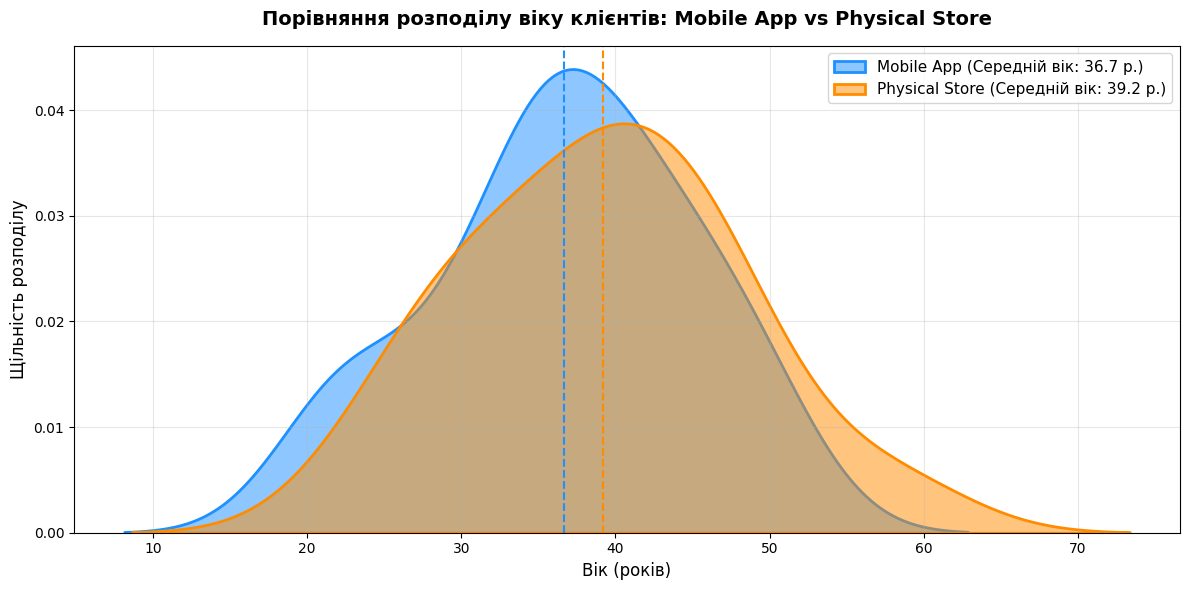

🧪 РЕЗУЛЬТАТИ СТАТИСТИЧНОГО Т-ТЕСТУ:
Середній вік у Mobile App: 36.67 років
Середній вік у Physical Store: 39.19 років
Т-статистика: -0.9190
p-value: 0.365469

🤷‍♂️ Результат: Різниця СТАТИСТИЧНО НЕЗНАЧУЩА (немає підстав відхилити H0).
Розбіжність у віці є випадковою коливаємостю даних.


In [8]:
# Об'єднуємо успішні продажі з даними клієнтів, щоб отримати їхній вік
df_age_channel = pd.merge(sales[sales['order_status'] == 'Completed'], clients, on='client_id', how='left')

# Виділяємо дві незалежні вибірки віку за каналами
age_app = df_age_channel[df_age_channel['sales_channel'] == 'Mobile App']['age'].dropna()
age_store = df_age_channel[df_age_channel['sales_channel'] == 'Physical Store']['age'].dropna()

# Виконуємо двовибірковий Т-тест (Т-тест Велча: equal_var=False)
t_stat, p_value = stats.ttest_ind(age_app, age_store, equal_var=False)

# Розраховуємо середні значення для опису висновків
mean_age_app = age_app.mean()
mean_age_store = age_store.mean()

# Візуалізація розподілів віку для двох каналів
plt.figure(figsize=(12, 6))

sns.kdeplot(age_app, fill=True, color="dodgerblue", label=f"Mobile App (Середній вік: {mean_age_app:.1f} р.)", alpha=0.5, linewidth=2)
sns.kdeplot(age_store, fill=True, color="darkorange", label=f"Physical Store (Середній вік: {mean_age_store:.1f} р.)", alpha=0.5, linewidth=2)

plt.title('Порівняння розподілу віку клієнтів: Mobile App vs Physical Store', fontsize=14, weight='bold', pad=15)
plt.xlabel('Вік (років)', fontsize=12)
plt.ylabel('Щільність розподілу', fontsize=12)
plt.axvline(mean_age_app, color='dodgerblue', linestyle='--', linewidth=1.5)
plt.axvline(mean_age_store, color='darkorange', linestyle='--', linewidth=1.5)
plt.legend(fontsize=11, loc='upper right')
plt.grid(axis='both', alpha=0.3)

plt.tight_layout()
plt.show()

# Вивід статистичних результатів
print("🧪 РЕЗУЛЬТАТИ СТАТИСТИЧНОГО Т-ТЕСТУ:")
print(f"Середній вік у Mobile App: {mean_age_app:.2f} років")
print(f"Середній вік у Physical Store: {mean_age_store:.2f} років")
print(f"Т-статистика: {t_stat:.4f}")
print(f"p-value: {p_value:.6f}")

# Автоматична інтерпретація для швидкої перевірки
if p_value < 0.05:
    print("\n🎉 Результат: Різниця СТАТИСТИЧНО ЗНАЧУЩА (відхиляємо нульову гіпотезу H0).")
    print("Вік клієнтів у цих каналах дійсно відрізняється не випадково.")
else:
    print("\n🤷‍♂️ Результат: Різниця СТАТИСТИЧНО НЕЗНАЧУЩА (немає підстав відхилити H0).")
    print("Розбіжність у віці є випадковою коливаємостю даних.")